In [1]:
# ============================================================
# Script 4.40 (Updated): Variational Quantum Eigensolver
# ============================================================
# PERUBAHAN QISKIT 2.x:
# - Estimator V1 DEPRECATED → StatevectorEstimator V2
# - API berbeda: run([(ansatz, observable, params)]) bukan run(ansatz, obs, params)
# - result().values[0] → result()[0].data.evs

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator   # V2: pengganti Estimator V1

# --- Definisi Hamiltonian ---
# H = 0.5·ZI + 0.5·IZ + 0.2·XX
hamiltonian = SparsePauliOp.from_list([("ZI", 0.5), ("IZ", 0.5), ("XX", 0.2)])

# --- Classical benchmark: diagonalisasi eksak ---
# Ini yang SEHARUSNYA ada di paper tapi tidak ada!
H_matrix   = hamiltonian.to_matrix()
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
E0_exact    = eigenvalues[0]
psi0_exact  = eigenvectors[:, 0]
print(f"Ground state energy (eksak): {E0_exact:.8f}")
print(f"Semua eigenvalues: {np.round(eigenvalues, 6)}")

# --- Setup Estimator V2 ---
estimator = StatevectorEstimator()

# --- Definisi Ansatz ---
# EfficientSU2: hardware-efficient ansatz, berlayer rotasi + CNOT
# Analogi: seperti neural network dengan layer activation dan connection,
# tapi di ruang Hilbert — sangat expressible tapi tanpa justifikasi fisika
ansatz = EfficientSU2(
    num_qubits=hamiltonian.num_qubits,
    reps=2,          # 2 repetisi layer → lebih expressible
    entanglement='linear'
)

print(f"\nAnsatz: {ansatz.num_parameters} parameter")
print(ansatz.decompose().draw(output='text'))

Ground state energy (eksak): -1.01980390
Semua eigenvalues: [-1.019804 -0.2       0.2       1.019804]

Ansatz: 12 parameter
     ┌──────────┐┌──────────┐     ┌──────────┐┌──────────┐     ┌──────────┐»
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[2]) ├──■──┤ Ry(θ[4]) ├┤ Rz(θ[6]) ├──■──┤ Ry(θ[8]) ├»
     ├──────────┤├──────────┤┌─┴─┐├──────────┤├──────────┤┌─┴─┐├──────────┤»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[3]) ├┤ X ├┤ Ry(θ[5]) ├┤ Rz(θ[7]) ├┤ X ├┤ Ry(θ[9]) ├»
     └──────────┘└──────────┘└───┘└──────────┘└──────────┘└───┘└──────────┘»
«     ┌───────────┐
«q_0: ┤ Rz(θ[10]) ├
«     ├───────────┤
«q_1: ┤ Rz(θ[11]) ├
«     └───────────┘


/tmp/ipykernel_3895916/4221065262.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


In [2]:
# --- Fungsi energy menggunakan Estimator V2 ---
energy_history = []   # untuk tracking konvergensi

def energy_v2(params, ansatz, hamiltonian, estimator):
    """
    Estimasi energy ⟨ψ(θ)|H|ψ(θ)⟩ menggunakan Estimator V2.
    
    Estimator V2 API (berbeda dari V1):
    - Input: list of PUBs (Primitive Unified Blocs)
      Setiap PUB = (circuit, observable, parameter_values)
    - Output: result()[0].data.evs
    
    Analogi: seperti mengirim "daftar pertanyaan" ke laboratorium kuantum.
    Tiap PUB = satu pertanyaan. Jawaban = nilai ekspektasi.
    """
    # Bind parameter ke ansatz
    bound_circuit = ansatz.assign_parameters(params)
    
    # Qiskit 2.x: format PUB untuk StatevectorEstimator
    pub    = (bound_circuit, hamiltonian)
    result = estimator.run([pub]).result()
    energy = result[0].data.evs   # scalar expectation value
    
    energy_history.append(float(energy))
    return float(energy)


# --- Verifikasi fungsi energy ---
test_params = np.zeros(ansatz.num_parameters)
e_test      = energy_v2(test_params, ansatz, hamiltonian, estimator)
print(f"\nEnergy pada θ=0: {e_test:.6f}")
energy_history.clear()  # reset untuk optimisasi


# --- Optimisasi COBYLA ---
np.random.seed(42)  # reproducibility
initial_params = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)

print(f"\nMemulai VQE dengan COBYLA...")
print(f"  {ansatz.num_parameters} parameter, random initialization")
print(f"  Energy awal: {energy_v2(initial_params, ansatz, hamiltonian, estimator):.6f}")
energy_history.clear()

result_cobyla = minimize(
    energy_v2,
    initial_params,
    args=(ansatz, hamiltonian, estimator),
    method='COBYLA',
    options={
        'maxiter': 1000,
        'rhobeg':  0.5,   # initial simplex size — penting untuk konvergensi
        'disp':    False
    }
)

final_params_cobyla = result_cobyla.x
E0_cobyla           = result_cobyla.fun
history_cobyla      = energy_history.copy()

print(f"\n--- Hasil COBYLA ---")
print(f"  Ground state energy (VQE-COBYLA): {E0_cobyla:.8f}")
print(f"  Ground state energy (eksak):      {E0_exact:.8f}")
print(f"  Error absolut: {abs(E0_cobyla - E0_exact):.2e}")
print(f"  Konvergen: {result_cobyla.success} ({result_cobyla.nfev} evaluasi)")


Energy pada θ=0: 1.000000

Memulai VQE dengan COBYLA...
  12 parameter, random initialization
  Energy awal: 0.332229

--- Hasil COBYLA ---
  Ground state energy (VQE-COBYLA): -1.01980390
  Ground state energy (eksak):      -1.01980390
  Error absolut: 2.05e-09
  Konvergen: True (207 evaluasi)


In [3]:
# --- Perbandingan dengan SPSA (gradient-free tapi lebih cocok untuk noise) ---
from scipy.optimize import minimize

def spsa_minimize(func, x0, args, n_iter=200, a=0.1, c=0.05, A=10, alpha=0.602, gamma=0.101):
    """
    Implementasi manual SPSA (Simultaneous Perturbation Stochastic Approximation).
    
    SPSA berbeda dari COBYLA:
    - Hanya butuh 2 evaluasi per iterasi (bukan n_params)
    - Lebih tahan noise → lebih cocok untuk real quantum hardware
    
    Analogi: COBYLA seperti penjelajah yang mengukur kemiringan setiap arah satu per satu.
    SPSA seperti penjelajah yang melompat acak ke dua arah sekaligus dan mengukur
    perbedaan ketinggian — lebih kasar tapi jauh lebih cepat.
    """
    spsa_history = []
    theta = x0.copy()
    
    for k in range(1, n_iter + 1):
        # Decay rates
        ak = a / (k + A) ** alpha
        ck = c / k ** gamma
        
        # Random perturbation vektor Bernoulli ±1
        delta = 2 * (np.random.randint(0, 2, len(theta)) - 0.5)
        
        # Dua evaluasi fungsi
        f_plus  = func(theta + ck * delta, *args)
        f_minus = func(theta - ck * delta, *args)
        
        # Estimasi gradient
        g_hat = (f_plus - f_minus) / (2 * ck * delta)
        
        # Update
        theta -= ak * g_hat
        spsa_history.append(func(theta, *args))
    
    return theta, spsa_history


energy_history.clear()
np.random.seed(42)
initial_params_spsa = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)

final_params_spsa, history_spsa = spsa_minimize(
    energy_v2,
    initial_params_spsa,
    args=(ansatz, hamiltonian, estimator),
    n_iter=300
)

E0_spsa = energy_v2(final_params_spsa, ansatz, hamiltonian, estimator)
print(f"\n--- Hasil SPSA ---")
print(f"  Ground state energy (VQE-SPSA): {E0_spsa:.8f}")
print(f"  Ground state energy (eksak):    {E0_exact:.8f}")
print(f"  Error absolut: {abs(E0_spsa - E0_exact):.2e}")


--- Hasil SPSA ---
  Ground state energy (VQE-SPSA): -0.80459330
  Ground state energy (eksak):    -1.01980390
  Error absolut: 2.15e-01


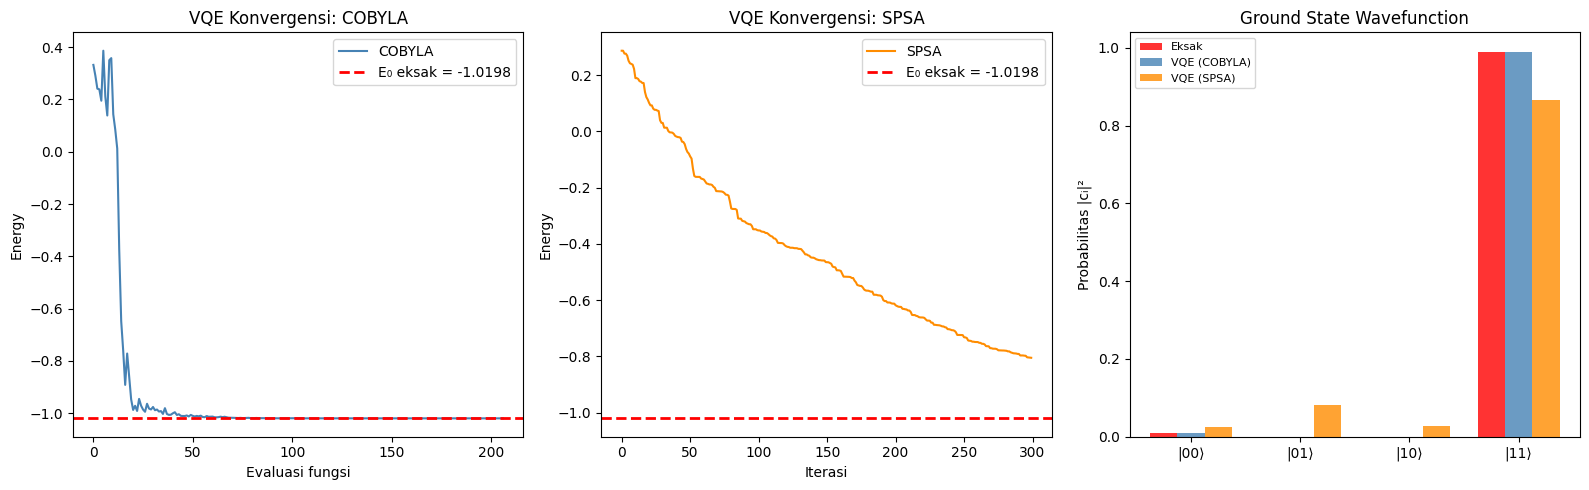


Fidelity |⟨ψ_eksak|ψ_VQE⟩|²:
  COBYLA: 1.000000
  SPSA:   0.848797


In [4]:
# --- Visualisasi komprehensif ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Konvergensi COBYLA
ax = axes[0]
ax.plot(history_cobyla, '-', lw=1.5, color='steelblue', label='COBYLA')
ax.axhline(E0_exact, color='red', ls='--', lw=2, label=f'E₀ eksak = {E0_exact:.4f}')
ax.set_xlabel('Evaluasi fungsi')
ax.set_ylabel('Energy')
ax.set_title('VQE Konvergensi: COBYLA')
ax.legend()

# 2. Konvergensi SPSA
ax = axes[1]
ax.plot(history_spsa, '-', lw=1.5, color='darkorange', label='SPSA')
ax.axhline(E0_exact, color='red', ls='--', lw=2, label=f'E₀ eksak = {E0_exact:.4f}')
ax.set_xlabel('Iterasi')
ax.set_ylabel('Energy')
ax.set_title('VQE Konvergensi: SPSA')
ax.legend()

# 3. Perbandingan wavefunctions
ax = axes[2]
psi_vqe_cobyla = np.array(Statevector(ansatz.assign_parameters(final_params_cobyla)))
psi_vqe_spsa   = np.array(Statevector(ansatz.assign_parameters(final_params_spsa)))

labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
x      = np.arange(4)
ax.bar(x - 0.25, np.abs(psi0_exact)**2,     0.25, label='Eksak',        color='red',        alpha=0.8)
ax.bar(x,        np.abs(psi_vqe_cobyla)**2, 0.25, label='VQE (COBYLA)', color='steelblue',  alpha=0.8)
ax.bar(x + 0.25, np.abs(psi_vqe_spsa)**2,  0.25, label='VQE (SPSA)',   color='darkorange',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Probabilitas |cᵢ|²')
ax.set_title('Ground State Wavefunction')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Fidelity
fid_cobyla = np.abs(np.vdot(psi0_exact, psi_vqe_cobyla))**2
fid_spsa   = np.abs(np.vdot(psi0_exact, psi_vqe_spsa))**2
print(f"\nFidelity |⟨ψ_eksak|ψ_VQE⟩|²:")
print(f"  COBYLA: {fid_cobyla:.6f}")
print(f"  SPSA:   {fid_spsa:.6f}")